# Customer Churn EDA & Predictive Modeling
## Author: Pavlo Popovych
## Publication Date: February 7, 2026

Customer churn is one of the most critical challenges in the telecommunications industry, directly impacting revenue and long-term profitability. Retaining existing customers is significantly more cost-effective than acquiring new ones, making churn prediction a strategic priority.

The objective of this project is to analyze customer data and develop a predictive model that identifies customers who are most likely to churn. By leveraging demographic and service-related features, I aim to uncover key drivers of churn and quantify churn risk at the individual customer level.

# Step 0: Downloading Data

In [38]:
import kagglehub
import shutil
import os
import zipfile

cache_path = kagglehub.dataset_download("blastchar/telco-customer-churn", force_download=True)

print("Downloaded to cache:", cache_path)

project_dir = "../data/01_raw"
os.makedirs(project_dir, exist_ok=True)

if cache_path.endswith(".zip"):
    with zipfile.ZipFile(cache_path, 'r') as z:
        z.extractall(project_dir)
    print("Extracted to:", project_dir)
else:
    for filename in os.listdir(cache_path):
        shutil.copy(os.path.join(cache_path, filename), project_dir)
    print("Copied to:", project_dir)

100%|██████████| 172k/172k [00:00<00:00, 438kB/s]

Extracting files...
Downloaded to cache: /home/zxrcodev/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1
Copied to: ../data/01_raw


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline

print("Done")

Done


# Step 1: Data Loading

In [40]:
# Load dataset

# Construct path relative to notebook location
data_path = os.path.join('..', 'data', '01_raw', 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = pd.read_csv(data_path)

# Step 2: Data Wrangling

First-time data check

In [41]:
print(df.info())
print(df.describe(include='all'))
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


The TotalCharges column is currently stored as an object (string) data type and requires conversion to a numeric format to enable proper quantitative analysis.

The SeniorCitizen column is encoded as an integer (0/1), but it represents a categorical attribute rather than a continuous numerical variable and should therefore be treated as a categorical feature in the analysis.

In [42]:
df = df.drop(columns='customerID')
df['SeniorCitizen'] = df['SeniorCitizen'].astype(object)
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df.info())
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


After converting the TotalCharges column to numeric, some entries may become NaN (null) due to non-numeric values in the original object column. It’s important to check for these missing values and decide how to handle them—either by imputing, filling with zero/median, or removing affected rows—before proceeding with analysis.

In [43]:
df[df['TotalCharges'].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,No,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Exactly. Since the TotalCharges nulls correspond to new customers with no usage records or corrupted entries and they also have zero tenure, they don’t contribute meaningful information to the analysis. Dropping these rows is reasonable and won’t bias the dataset.

In [44]:
df = df.dropna(subset=['TotalCharges'])
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


# Step 3: Exploratory Data Analysis (EDA)

I will now examine how churn is distributed across the dataset.

<Axes: xlabel='Churn'>

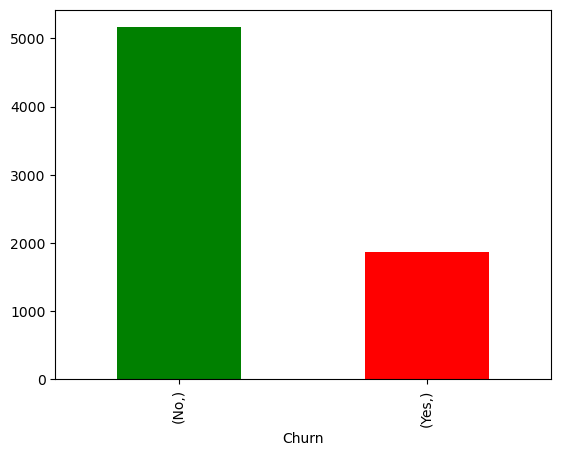

In [45]:
# Check churn distribution
churn = df[['Churn']].value_counts()
churn.plot(kind='bar', color=['green', 'red'])

The dataset does show class imbalance, and I will use this information later during modeling. Next, I am examining the distribution of categorical features with respect to churn.

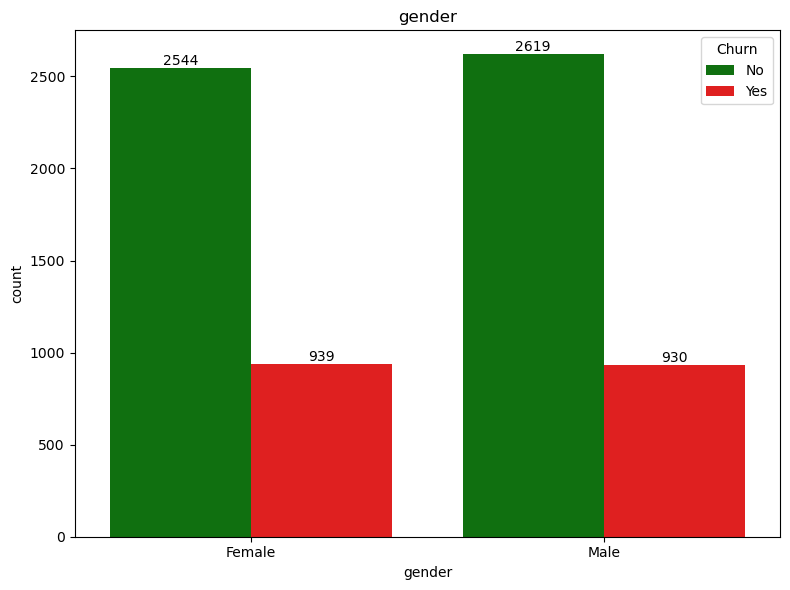

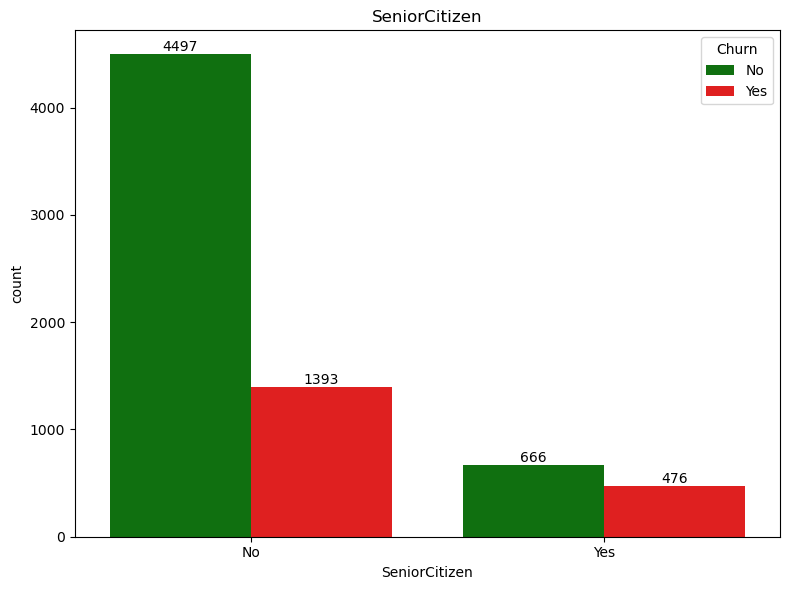

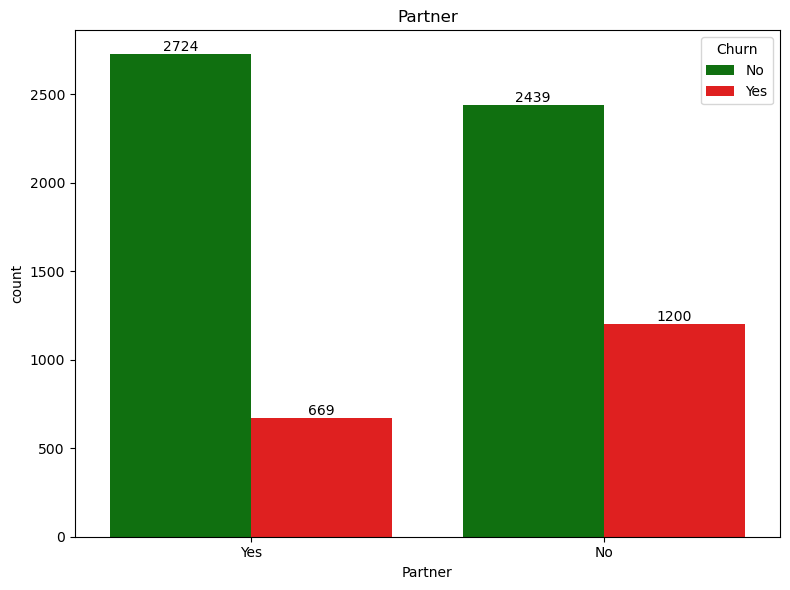

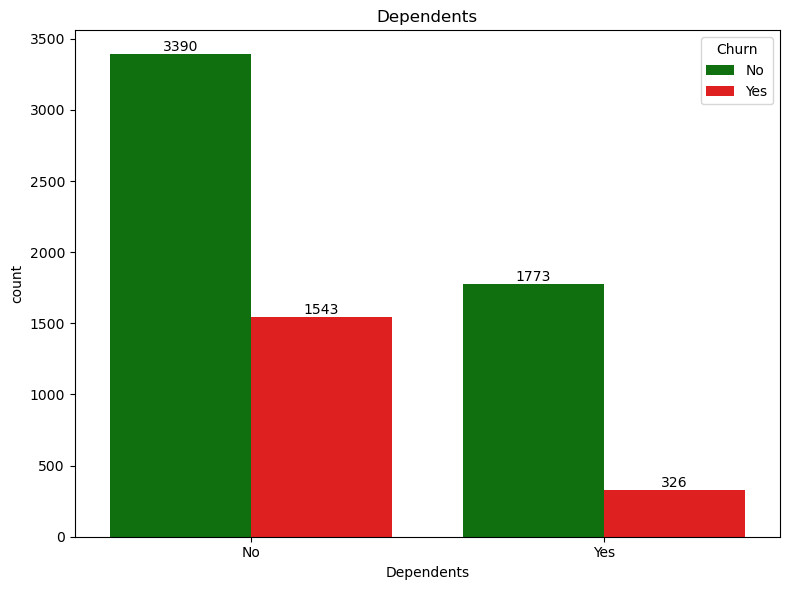

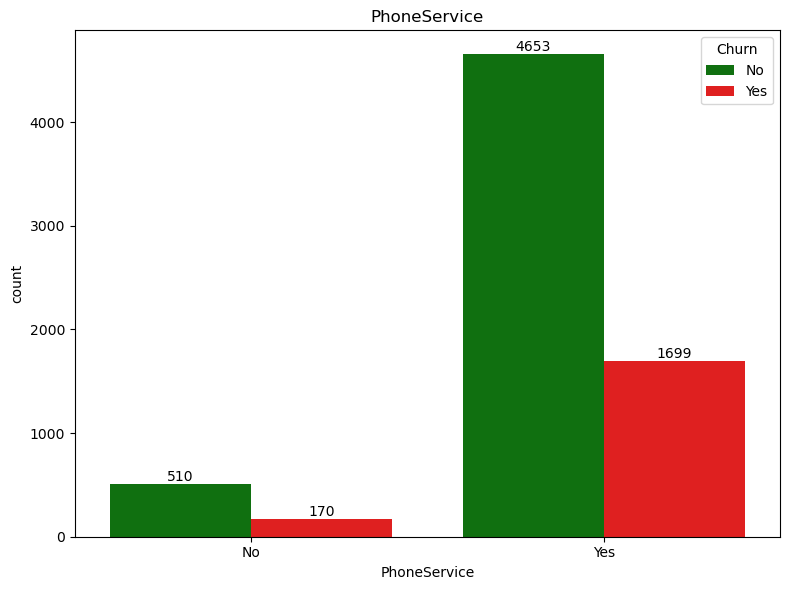

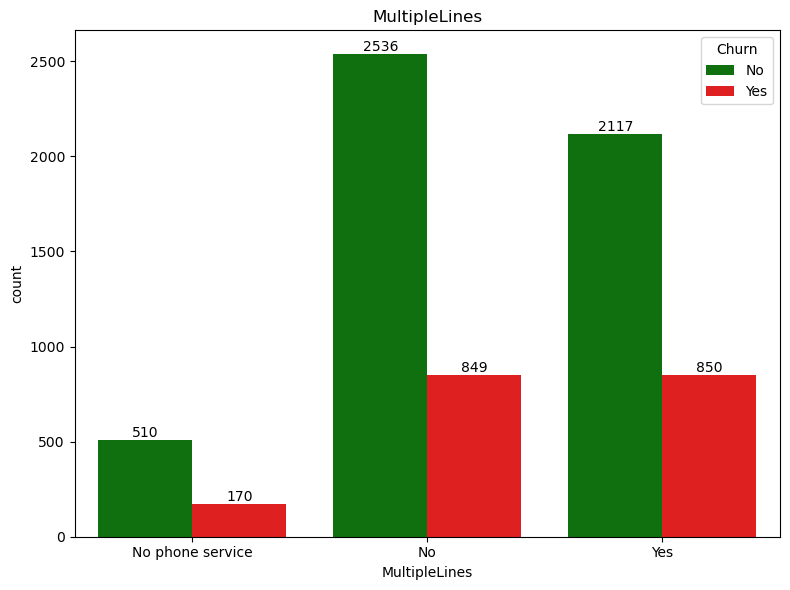

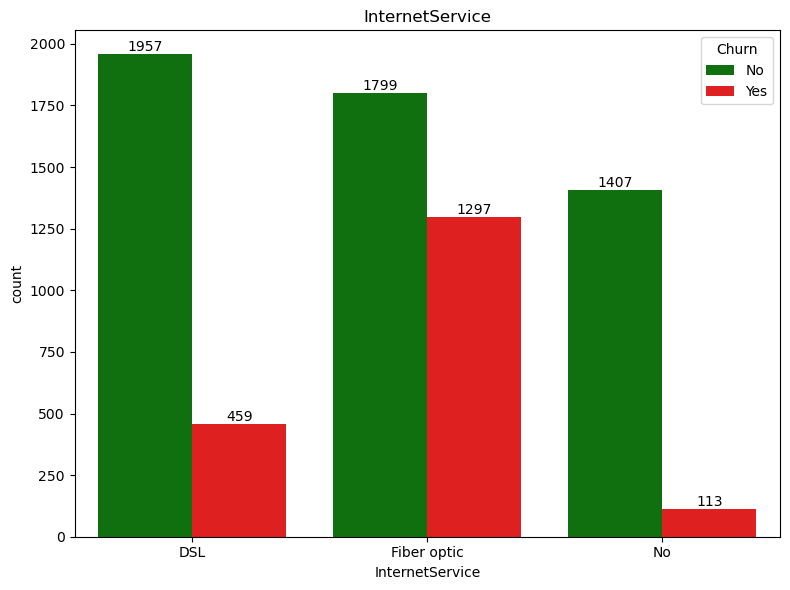

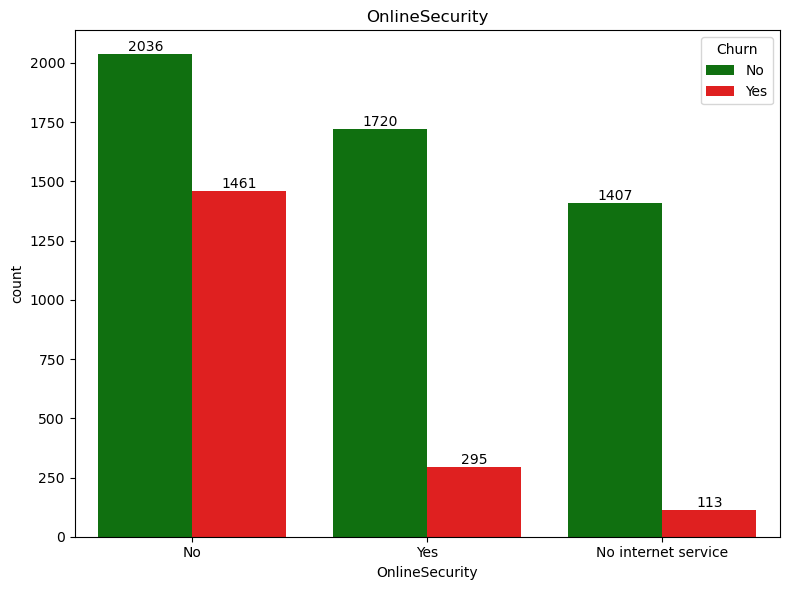

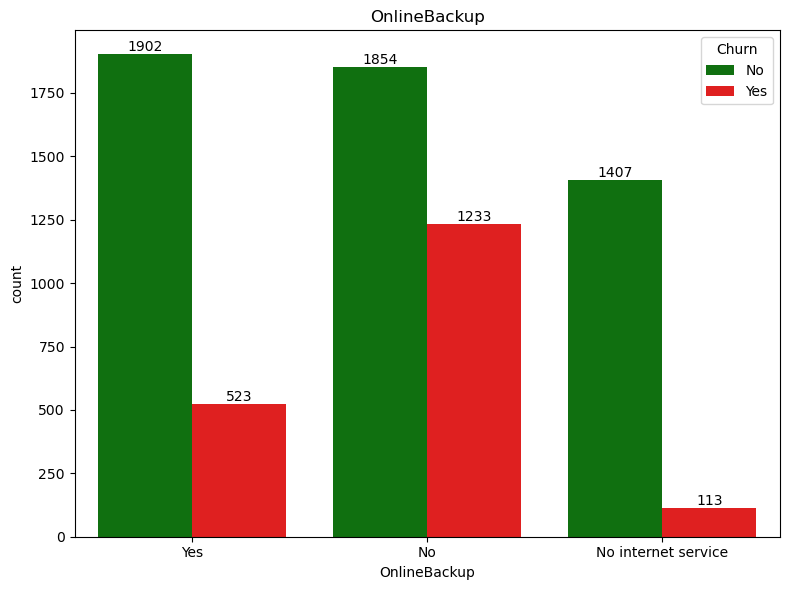

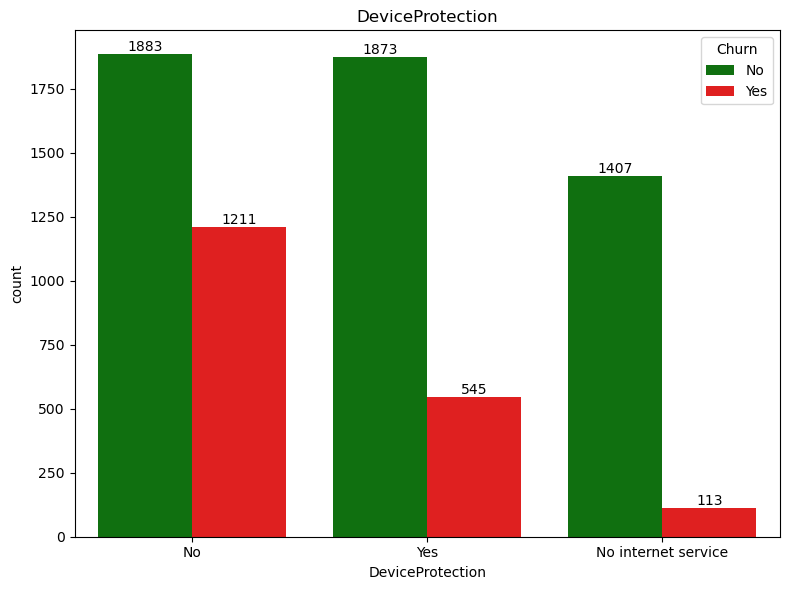

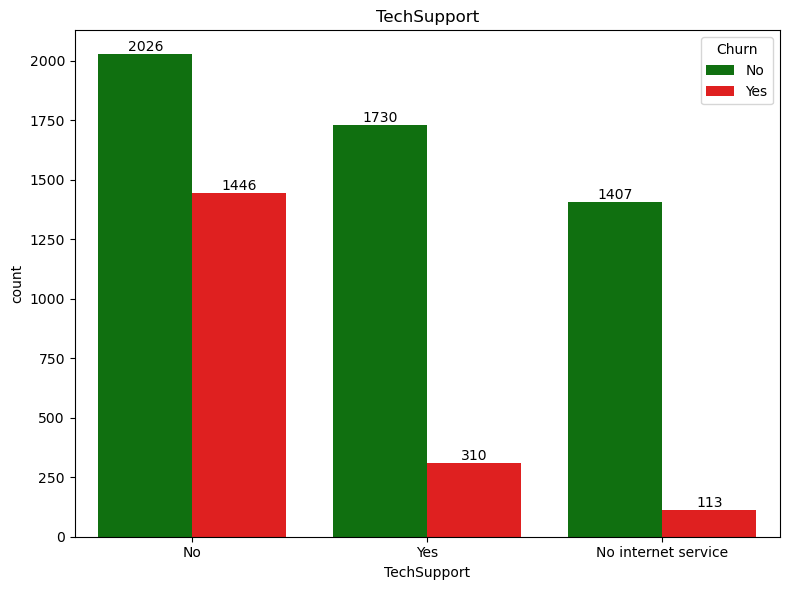

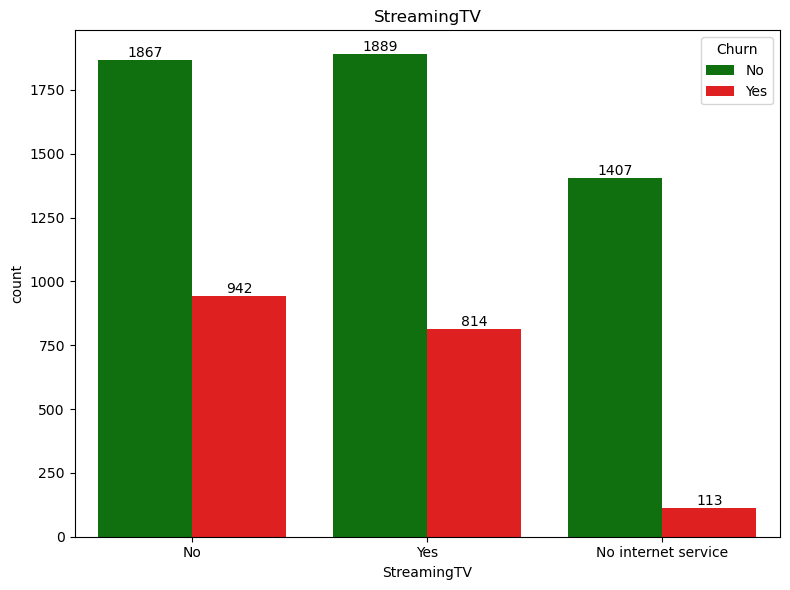

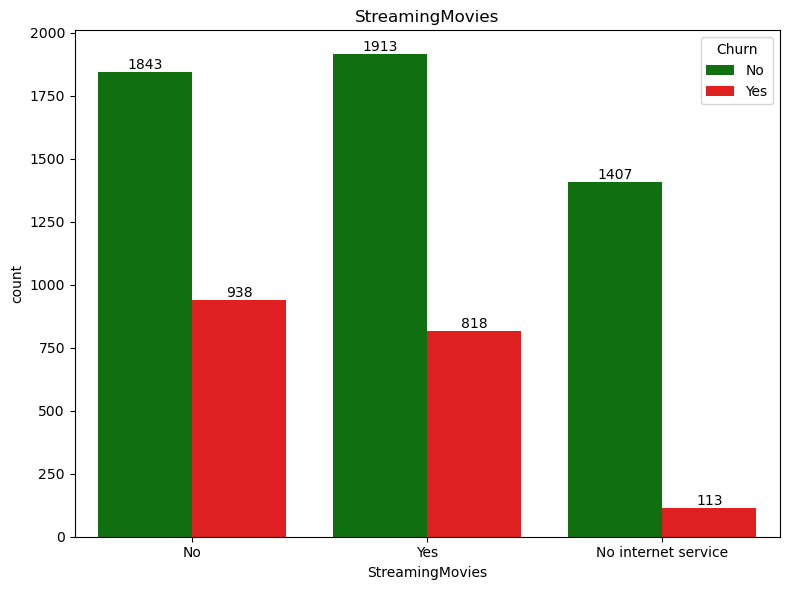

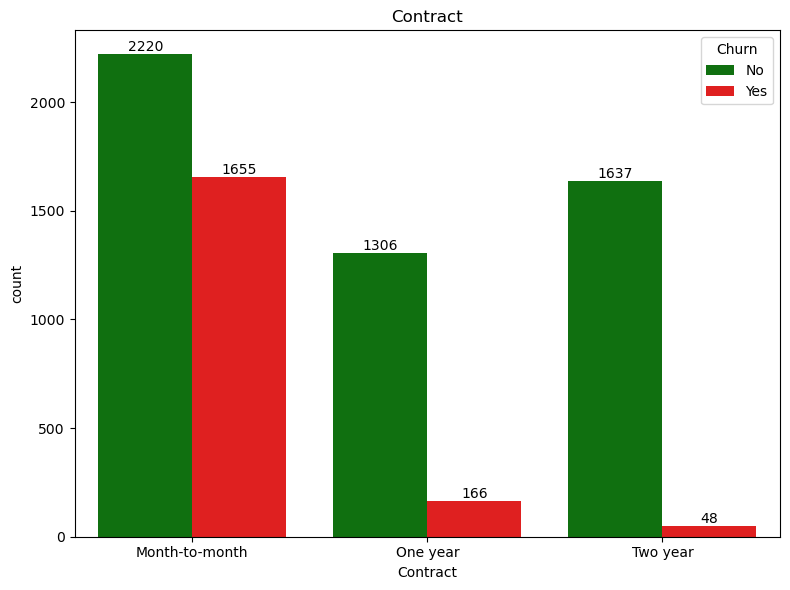

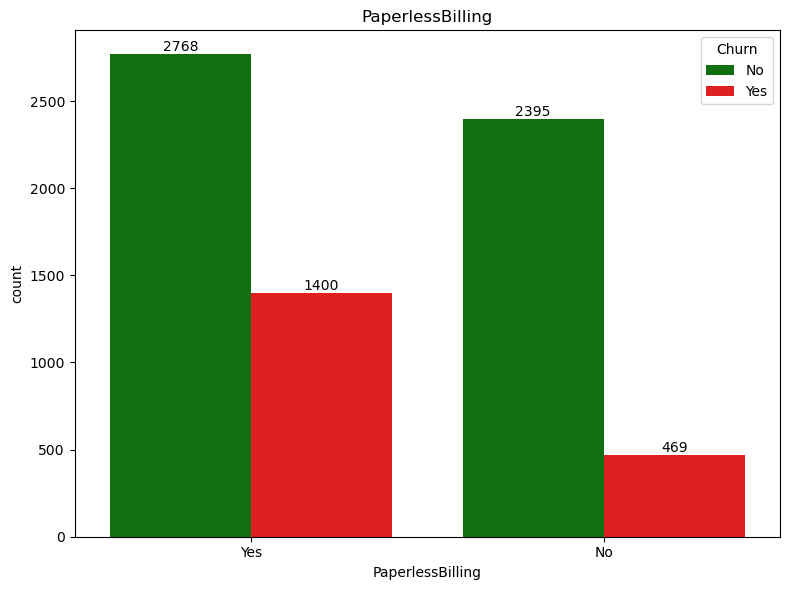

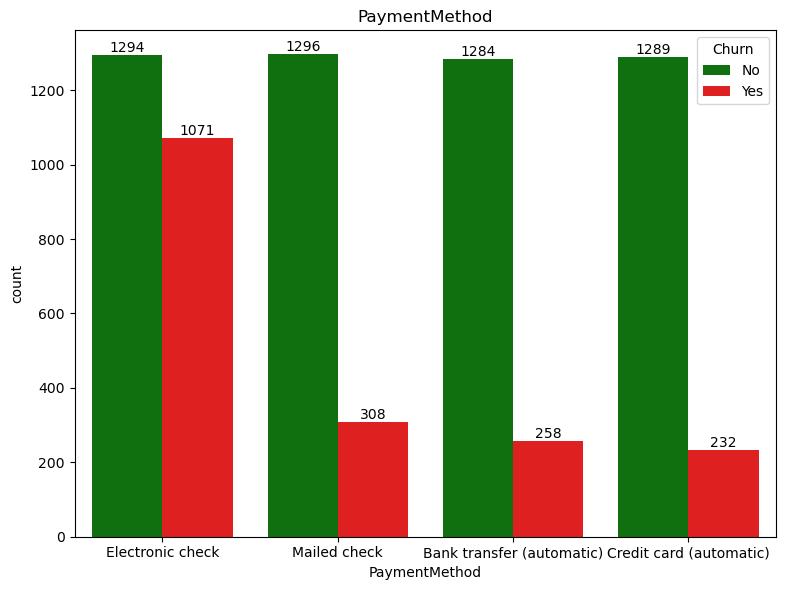

In [46]:
# Visualize categorical features wrt churn
categorical_cols = df.select_dtypes(include='object').drop(columns=['Churn']).columns
colors = {'Yes': 'red', 'No': 'green'}

for i, name in enumerate(categorical_cols):
    plt.figure(i, figsize=(8, 6))
    ax = sns.countplot(data=df, x=name, hue='Churn', palette=colors)
    plt.title(name)

    for container in ax.containers:
        ax.bar_label(container)
    
    plt.tight_layout()
    plt.show()

Here, I calculate the correlation of the features with respect to churn and visualize the results.

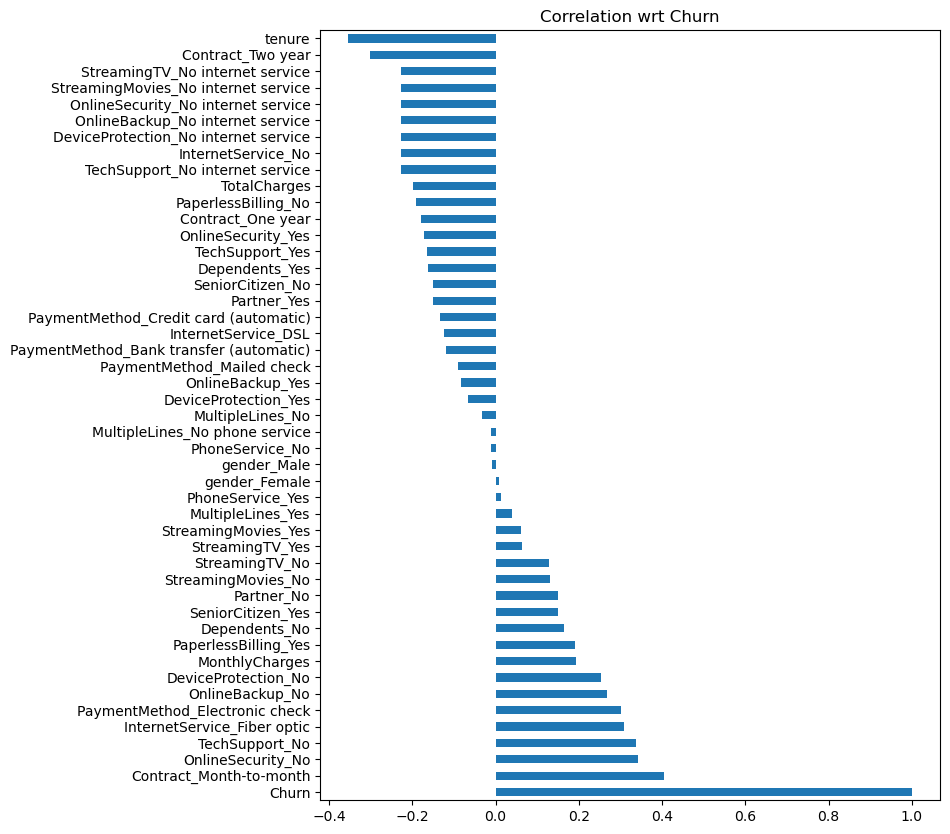

In [47]:
df_encoded_corr = pd.get_dummies(df, columns=categorical_cols)
df_encoded_corr['Churn'] = df_encoded_corr['Churn'].map({'Yes': 1, 'No': 0})

full_corr = df_encoded_corr.corr()
full_corr['Churn'].sort_values(ascending=False).plot(kind='barh', figsize=(8, 10))
plt.title('Correlation wrt Churn')
plt.show()

Using this information, I proceed to explore the most important features highlighted by the correlation plot.

<Axes: xlabel='Churn'>

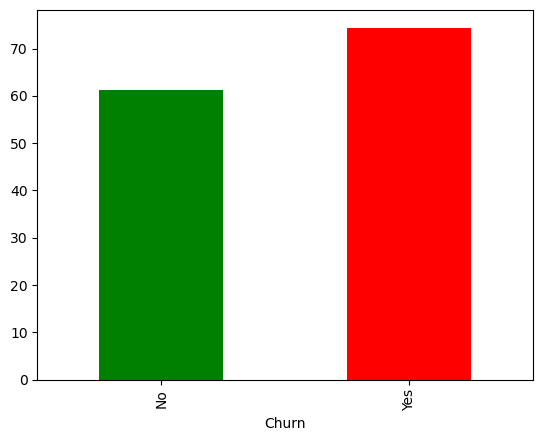

In [48]:
df.groupby('Churn')['MonthlyCharges'].mean().plot(kind='bar', color=['green', 'red'])

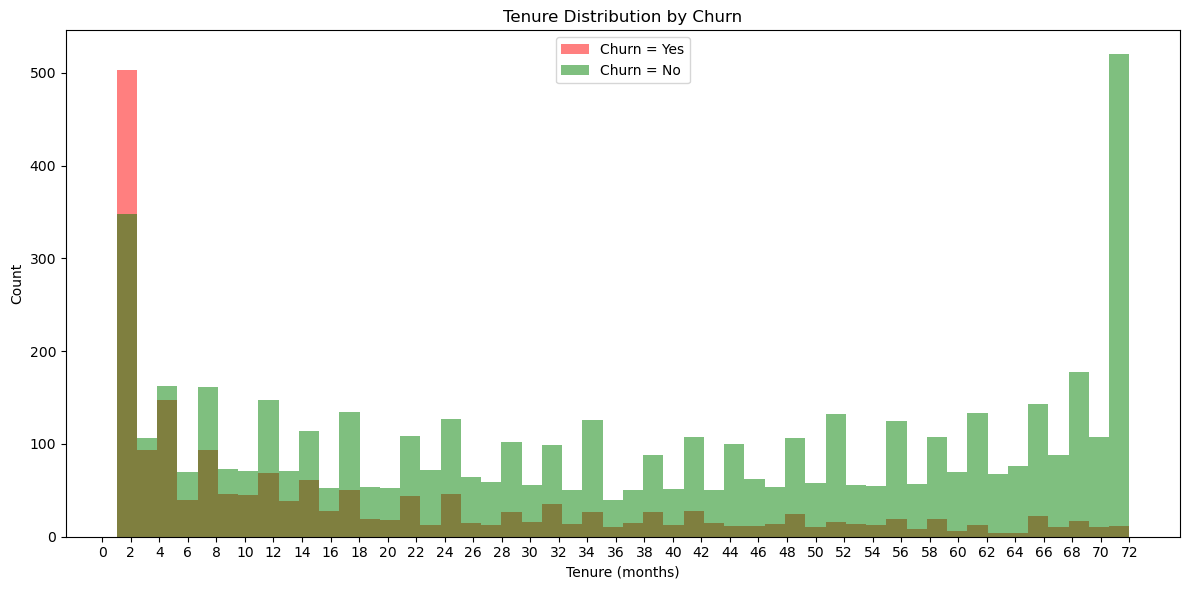

In [49]:
plt.figure(figsize=(12, 6))

plt.hist(
    df.loc[df['Churn'] == 'Yes', 'tenure'],
    bins=50,
    alpha=0.5,
    label='Churn = Yes',
    color='red'
)

plt.hist(
    df.loc[df['Churn'] == 'No', 'tenure'],
    bins=50,
    alpha=0.5,
    label='Churn = No',
    color='green'
)

plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.xticks(range(0, df['tenure'].max()+1, 2))
plt.legend()

plt.tight_layout()
plt.show()


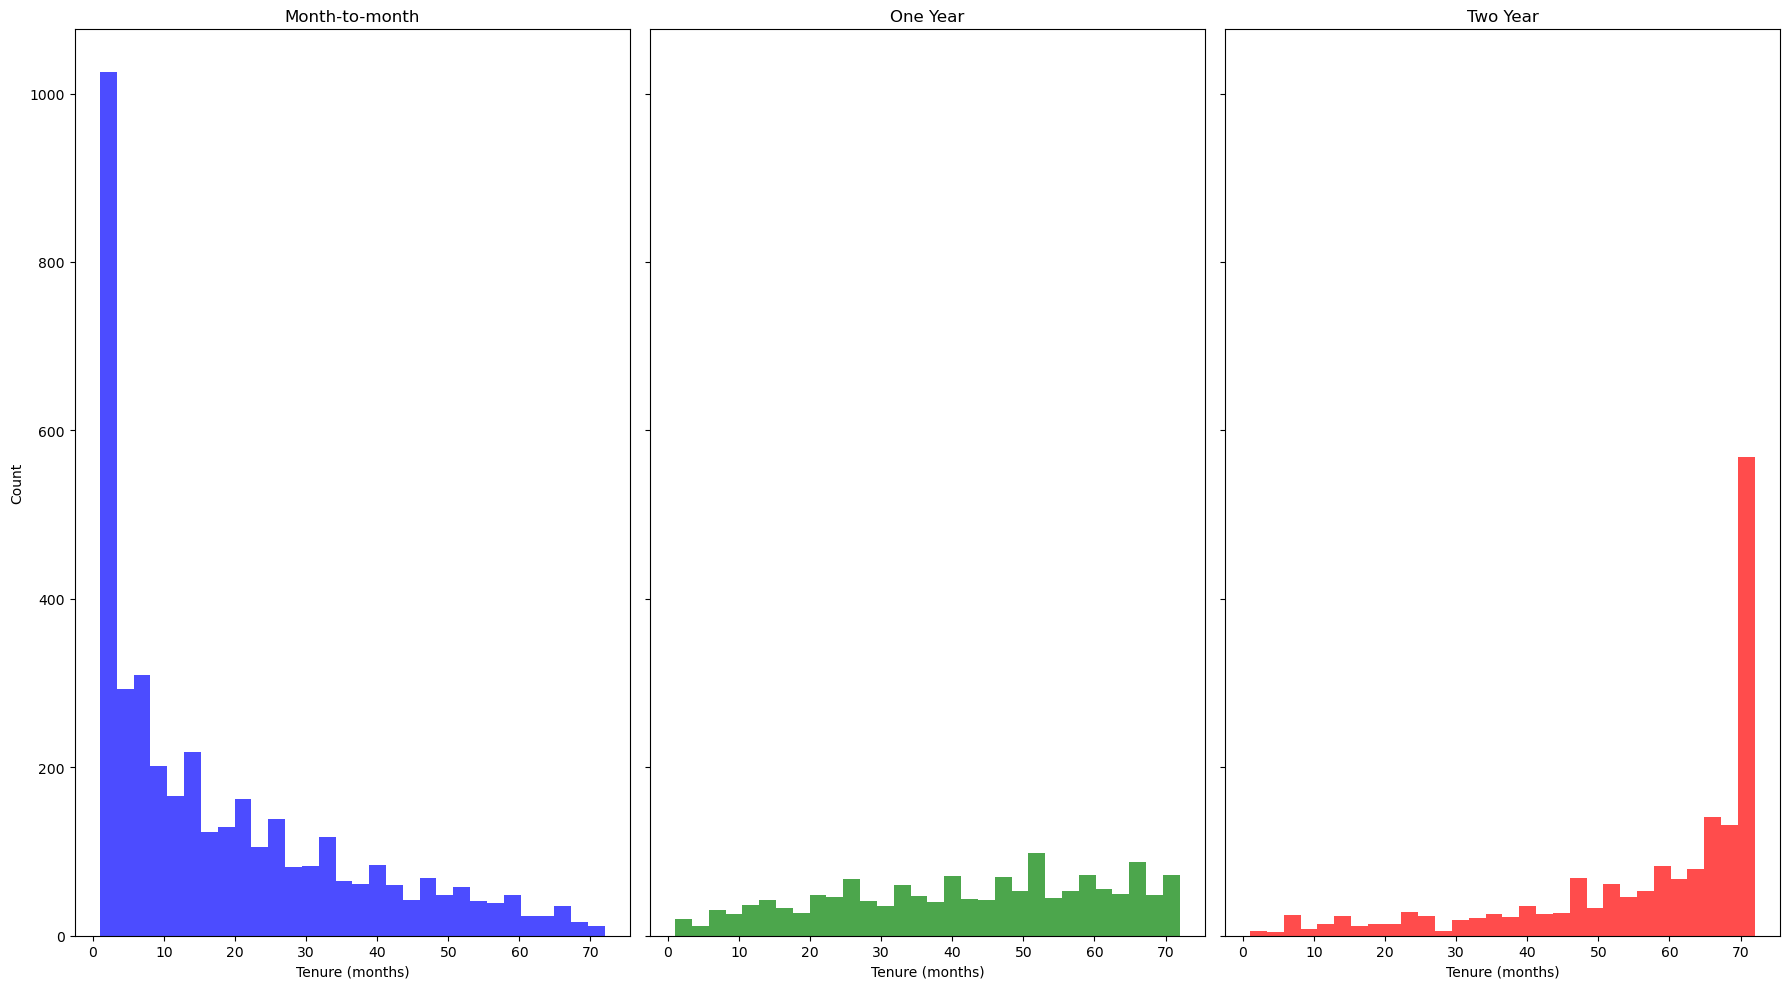

In [50]:
fig, ax = plt.subplots(1, 3, figsize=(18, 10), sharey=True)

df.loc[df['Contract'] == 'Month-to-month', 'tenure'].plot(
    kind='hist',
    bins=30,
    color='blue',
    alpha=0.7,
    ax=ax[0]
)
ax[0].set_title('Month-to-month')
ax[0].set_xlabel('Tenure (months)')
ax[0].set_ylabel('Count')

df.loc[df['Contract'] == 'One year', 'tenure'].plot(
    kind='hist',
    bins=30,
    color='green',
    alpha=0.7,
    ax=ax[1]
)
ax[1].set_title('One Year')
ax[1].set_xlabel('Tenure (months)')

df.loc[df['Contract'] == 'Two year', 'tenure'].plot(
    kind='hist',
    bins=30,
    color='red',
    alpha=0.7,
    ax=ax[2]
)
ax[2].set_title('Two Year')
ax[2].set_xlabel('Tenure (months)')

plt.tight_layout()
plt.show()


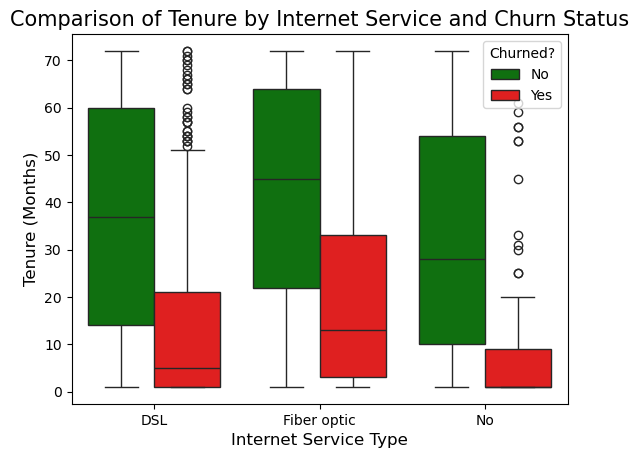

In [51]:
sns.boxplot(data=df, x='InternetService', y='tenure', hue='Churn', 
            palette={'Yes': 'red', 'No': 'green'})

plt.title('Comparison of Tenure by Internet Service and Churn Status', fontsize=15)
plt.xlabel('Internet Service Type', fontsize=12)
plt.ylabel('Tenure (Months)', fontsize=12)
plt.legend(title='Churned?')
plt.show()

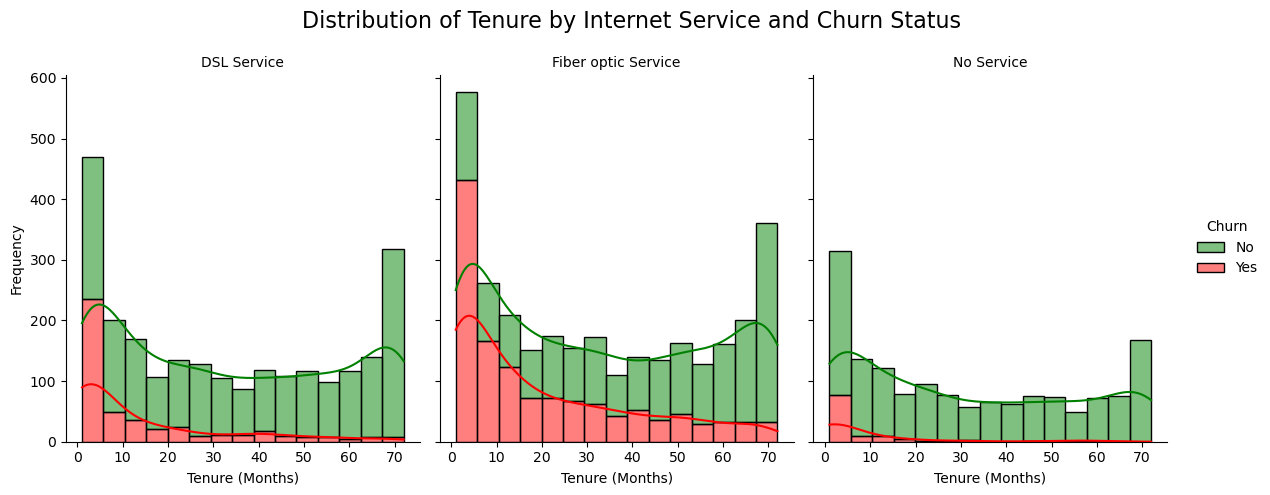

In [52]:
g = sns.displot(
    data=df, 
    x='tenure', 
    hue='Churn', 
    col='InternetService', 
    kind='hist', 
    kde=True,
    palette={'Yes': 'red', 'No': 'green'},
    multiple='stack',
    height=5, 
    aspect=0.8
)

g.set_axis_labels('Tenure (Months)', 'Frequency')
g.set_titles("{col_name} Service")
g.fig.suptitle('Distribution of Tenure by Internet Service and Churn Status', fontsize=16)

plt.subplots_adjust(top=0.85)
plt.show()

In [53]:
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 24, 36, 48, float('inf')]

labels = ['1 month', '2 months', '3 months', '4 months', '5 months', '6 months', 
          '7 months', '8 months', '9 months', '10 months', '11 months', '12 months',
          '2 years', '3 years', '4 years', '4+ years']

df['tenure_categorized'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=True)

/tmp/ipykernel_65563/1847252653.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tenure_categorized'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=True)


/tmp/ipykernel_65563/4259173281.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Churn_Rate'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
/tmp/ipykernel_65563/4259173281.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df.pivot_table(


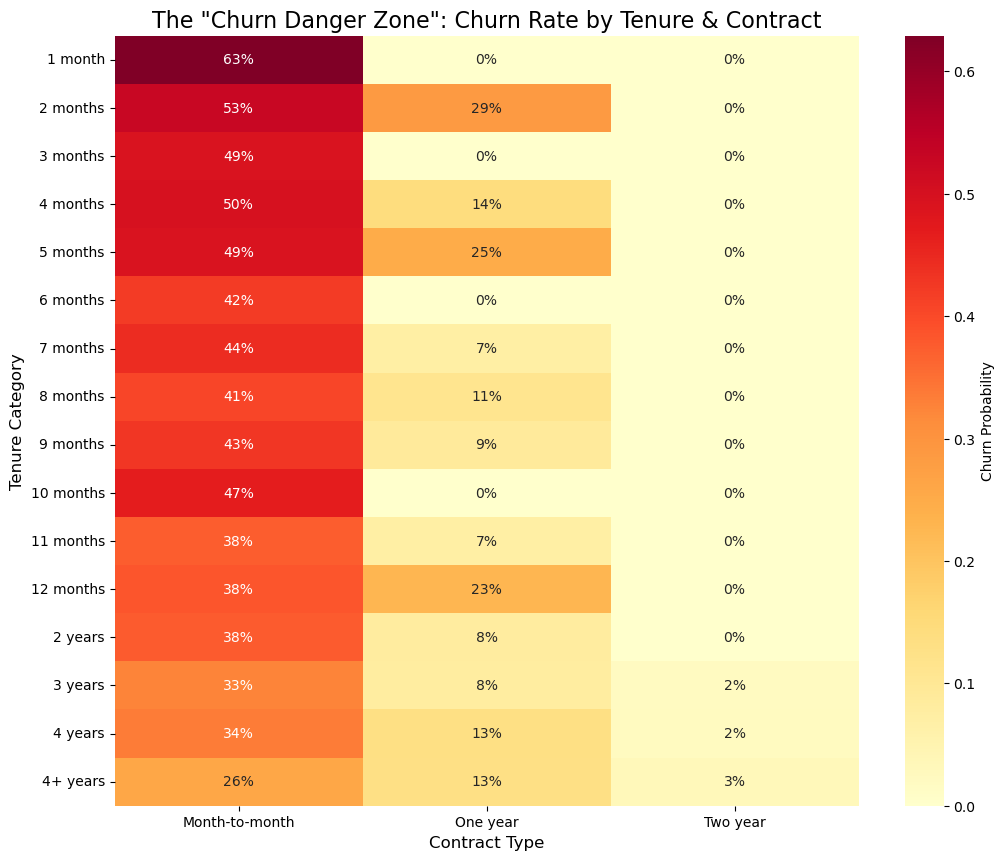

In [54]:
df['Churn_Rate'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

heatmap_data = df.pivot_table(
    index='tenure_categorized', 
    columns='Contract', 
    values='Churn_Rate', 
    aggfunc='mean'
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    heatmap_data, 
    annot=True,         
    fmt=".0%",           
    cmap="YlOrRd",       
    cbar_kws={'label': 'Churn Probability'}
)

plt.title('The "Churn Danger Zone": Churn Rate by Tenure & Contract', fontsize=16)
plt.ylabel('Tenure Category', fontsize=12)
plt.xlabel('Contract Type', fontsize=12)
plt.show()

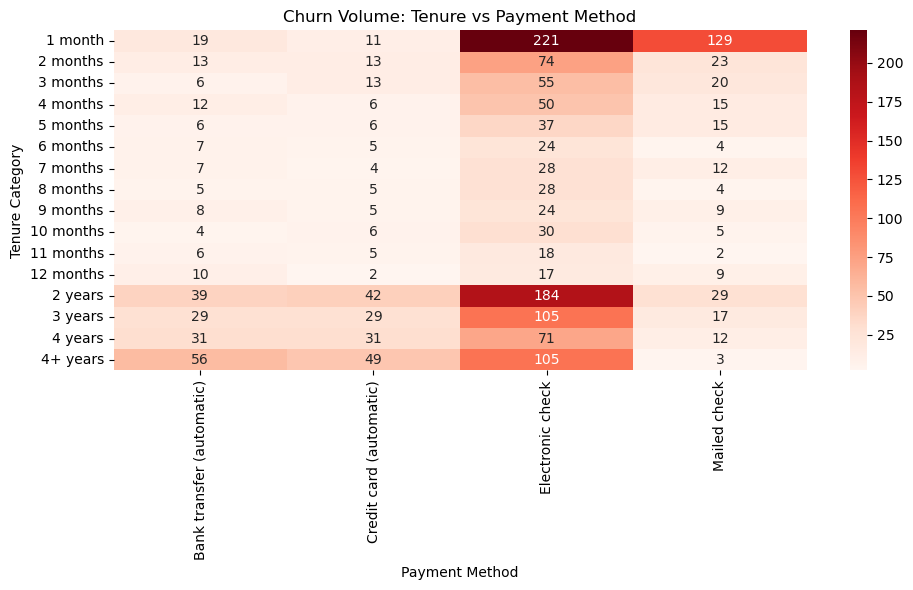

In [55]:
churned_df = df[df['Churn'] == 'Yes'].copy()

pivot_table = pd.crosstab(
    churned_df['tenure_categorized'],
    churned_df['PaymentMethod']
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title('Churn Volume: Tenure vs Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Tenure Category')

plt.tight_layout()
plt.show()


In [56]:
df.drop(columns=['Churn_Rate','tenure_categorized'], inplace=True)

pd_to_csv_path = os.path.join('..', 'data', '02_processed', 'churn_eda_processed.csv')

os.makedirs(os.path.dirname(pd_to_csv_path), exist_ok=True)

df.to_csv(pd_to_csv_path, index=False)

print(f"CSV saved to {pd_to_csv_path}")

CSV saved to ../data/02_processed/churn_eda_processed.csv


/tmp/ipykernel_65563/706098009.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['Churn_Rate','tenure_categorized'], inplace=True)


## EDA Summary

### Key Insights
1. **Early “Danger Zone”:** Churn is highest within the first 1–5 months of tenure, largely driven by month-to-month subscribers. Among new customers (up to month 10) on month-to-month contracts, churn exceeds 50%. Overall, month-to-month users exhibit the highest churn rate at 56.89%. Notably, a substantial portion of the customer base falls within the 1–10 month tenure window, amplifying early-stage risk exposure.
2. **Payment Friction**: Customers using manual payment methods (Electronic Check or Mailed Check) show significantly higher churn compared to those on automated billing. Manual payers churn at 34.74%, versus 16.00% for automated payment users (high statistical confidence). This effect is particularly pronounced among customers in their first 1–2 months, suggesting early billing friction may accelerate attrition. Automated payment users demonstrate materially stronger retention.
3. **Service Mismatch**: Long-tenure Fiber Optic customers exhibit elevated churn, indicating potential service instability, pricing sensitivity, or unmet expectations. In contrast, DSL customers show comparatively stronger retention stability. This pattern may intersect with insufficient technical support coverage among Fiber users.
4. **Lack of Technical Support**: Customers without technical support display materially higher churn (41.65%). This is especially evident among longer-tenure customers, potentially indicating unresolved service quality issues — particularly within the Fiber segment — that remain insufficiently addressed

### Retention Plan: The First 90 Days
- **Proactive Onboarding**: Implement structured “Health Check” calls during the first two months to identify and resolve early technical or billing concerns. (Insights 1, 2, 4)
- **Short-Term Incentives**: Provide targeted, time-bound incentives to high-risk customers in months 1–4 who are not yet ready to commit to long-term contracts. (Insight 1)
- **Automated Billing Incentives**: Offer a one-time financial incentive to transition manual payers to autopay, reducing friction and improving retention probability. (Insights 2, 4)
- **Contract Migration**: Encourage month-to-month subscribers to convert to 1–2 year contracts through loyalty-based offers and value positioning. (Insight 1)
- **Stability Optimization**: Prioritize technical support outreach and infrastructure/hardware optimization for at-risk Fiber customers. (Insights 3, 4)

**Conclusion:**  
Given the high concentration of customers in early tenure stages and the disproportionate churn risk within the first 5 months, immediate investment in early-life retention initiatives is critical. Addressing onboarding friction, billing automation, and service stability will materially reduce churn and strengthen long-term revenue sustainability.

If approved, I can prepare a formal executive PDF report for stakeholders outlining the primary churn drivers identified, the recommended mitigation strategy, and references to the supporting analytical charts.

# Step 4: Feature Engineering

I perform a chi-squared test to assess the statistical significance of the features and remove those that are not important, reducing noise in the dataset.

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency
import os

In [58]:
data_path = os.path.join('..', 'data', '02_processed', 'churn_eda_processed.csv')
df = pd.read_csv(data_path)

In [59]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols.remove('Churn')
results = []

for col in cat_cols:
    table = pd.crosstab(df[col], df["Churn"])
    chi2, p, dof, expected = chi2_contingency(table)

    results.append({
        "Feature": col,
        "Chi2": chi2,
        "p_value": p
    })

results_df = pd.DataFrame(results).sort_values("p_value")
results_df


,Feature,Chi2,p_value
13,Contract,1179.545829,7.326182e-257
7,OnlineSecurity,846.677389,1.400687e-184
10,TechSupport,824.925564,7.407808e-180
6,InternetService,728.695614,5.831199e-159
15,PaymentMethod,645.429900,1.426310e-139
8,OnlineBackup,599.175185,7.776099e-131
9,DeviceProtection,555.880327,1.959389e-121
12,StreamingMovies,374.268432,5.353560e-82
11,StreamingTV,372.456502,1.324641e-81
14,PaperlessBilling,256.874908,8.236203e-58


I perform feature engineering to improve model performance and verify that all new features have been created and transformed successfully.

In [60]:
service_columns = [
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'PhoneService'
]

#df.loc[:, 'Tenure_risk_cohorts'] = pd.cut(
#    df['tenure'], 
#    bins=[0, 4, 12, 36, 48, 100], 
#    labels=['risk_category', 'new_category', 'medium_category', 'established_category', 'loyal_category']
#)

df.loc[:, 'High_Risk_Tenure'] = pd.cut(
    df['tenure'], 
    bins=[0, 4, 12, 100], 
    labels=['high_risk_category', 'medium_risk_category', 'low_risk_category']
)

contract_stability = {'Month-to-month': 1, 'One year': 2, 'Two year': 3}
df['Contract_Stability'] = df['Contract'].map(contract_stability)

df['Fiber_No_Support'] = (
    (df['InternetService'] == 'Fiber optic') & 
    (df['TechSupport'] == 'No')
).astype(int)

df['Manual_Payment_Early'] = (
    (df['PaymentMethod'].isin(['Electronic check', 'Mailed check'])) & 
    (df['tenure'] <= 6)
).astype(int)

df['High_Risk_New_Montly'] = (
    (df['tenure'] <= 6) & 
    (df['Contract'] == 'Month-to-month')
).astype(int)

new_boolean_features = [
    'Fiber_No_Support',
    'Manual_Payment_Early',
    'High_Risk_New_Montly'
]

df[new_boolean_features] = df[new_boolean_features].astype(bool)

for i in df.columns:
    print(f"{i}: {df[i].unique()}")
print(df.dtypes)
df.isnull().sum()

gender: ['Female' 'Male']
SeniorCitizen: ['No' 'Yes']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalC

gender                  0
SeniorCitizen           0
Partner                 0
Dependents              0
tenure                  0
PhoneService            0
MultipleLines           0
InternetService         0
OnlineSecurity          0
OnlineBackup            0
DeviceProtection        0
TechSupport             0
StreamingTV             0
StreamingMovies         0
Contract                0
PaperlessBilling        0
PaymentMethod           0
MonthlyCharges          0
TotalCharges            0
Churn                   0
High_Risk_Tenure        0
Contract_Stability      0
Fiber_No_Support        0
Manual_Payment_Early    0
High_Risk_New_Montly    0
dtype: int64

I drop columns identified as unnecessary by the chi-squared test, as well as features that are no longer needed following feature engineering.

In [61]:
df = df.drop(['gender', 'Contract'], axis=1)
df = df.drop(service_columns, axis=1)

In [62]:
pd_to_csv_path = os.path.join('..', 'data', '03_featured', 'churn_featured.csv')

os.makedirs(os.path.dirname(pd_to_csv_path), exist_ok=True)

df.to_csv(pd_to_csv_path, index=False)

print(f"CSV saved to {pd_to_csv_path}")

CSV saved to ../data/03_featured/churn_featured.csv


# Step 5: Predictive Modeling

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.feature_selection import mutual_info_classif
import warnings
import logging
import os

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, 
    ConfusionMatrixDisplay, precision_recall_curve, auc, roc_curve
)

warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.utils.validation')
logging.getLogger('lightgbm').setLevel(logging.ERROR)

In [64]:
data_path = os.path.join('..', 'data', '03_featured', 'churn_featured.csv')
df = pd.read_csv(data_path)

I prepare the dataset for modeling by splitting it into training and test sets, applying necessary transformations, and creating preprocessors for both tree-based models and logistic regression. To avoid data leakage I will implement imbalance handling tools inside models' pipelines, not performing SMOTE over the whole dataset.

In [65]:
X = df.drop(columns='Churn')
Y = df['Churn'].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=11, stratify=Y)

num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

cv_trees = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)

preprocessor_trees = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(), cat_cols)
    ]
)

preprocessor_log = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ],
)

## Logistic Regression Model

In [66]:
model_pipeline = ImbPipeline([
    ('pre', preprocessor_log),
    ('smote', SMOTE(random_state=11)),
    ('classifier', LogisticRegression(max_iter=1000, solver='liblinear', verbose=0))
])


param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2']
}

grid_search = GridSearchCV(
    model_pipeline, 
    param_grid, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

best_log_model = grid_search.best_estimator_

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407



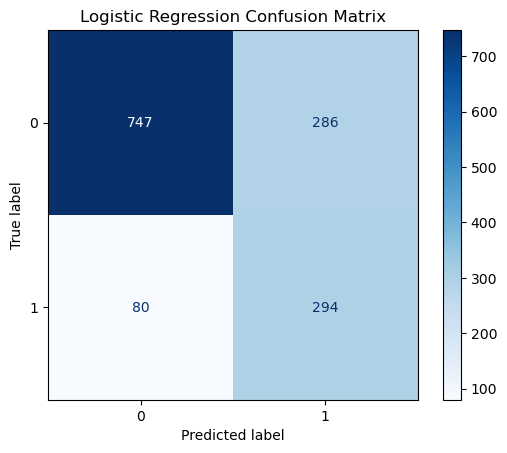

In [67]:
y_pred = best_log_model.predict(X_test)
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(best_log_model, X_test, y_test, cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## XGBoost Model

In [68]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = float(neg / pos)

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor_trees),
    ('classifier', XGBClassifier(
        random_state=11,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        verbosity=0
    ))
])

param_grid_xgb = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=cv_trees,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

grid_search_xgb.fit(X_train, y_train)

best_xgb_model = grid_search_xgb.best_estimator_
print("Best params:", grid_search_xgb.best_params_)


Best params: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}


              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1033
           1       0.51      0.77      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.76      1407



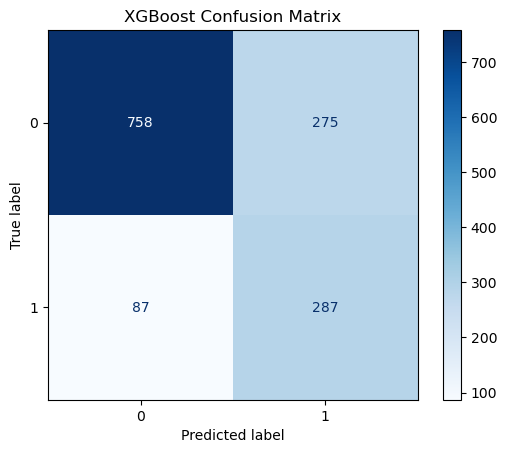

In [69]:
y_pred_xgb = best_xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb))
ConfusionMatrixDisplay.from_estimator(best_xgb_model, X_test, y_test, cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.show()

## Random Forest Model

In [70]:
rfc_pipeline = Pipeline([
    ('pre', preprocessor_trees),
    ('classifier', RandomForestClassifier(
        random_state=11,
        n_jobs=1,
        verbose=0
    ))
])

param_grid_rfc = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__max_features': ['sqrt', 'log2']
}

grid_search_rfc = GridSearchCV(
    rfc_pipeline, 
    param_grid_rfc, 
    cv=cv_trees, 
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=0
)

grid_search_rfc.fit(X_train, y_train)

best_rfc_model = grid_search_rfc.best_estimator_

              precision    recall  f1-score   support

           0       0.83      0.91      0.86      1033
           1       0.65      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



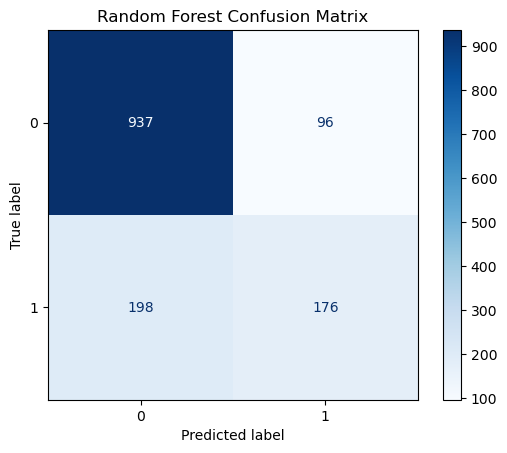

In [71]:
y_pred_rfc = best_rfc_model.predict(X_test)
print(classification_report(y_test, y_pred_rfc))
ConfusionMatrixDisplay.from_estimator(best_rfc_model, X_test, y_test, cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

## LightGBM Model

In [72]:
lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor_trees),
    ('classifier', LGBMClassifier(
        random_state=11,
        importance_type='gain',
        n_jobs=1,
        class_weight='balanced',
        boosting_type='gbdt',
        verbose=0
    ))
])

param_grid_lgbm = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__num_leaves': [31, 50, 63],
    'classifier__max_depth': [10, 15, 20]
}

grid_search_lgbm = GridSearchCV(
    lgbm_pipeline, 
    param_grid_lgbm, 
    cv=cv_trees, 
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=0
    )

grid_search_lgbm.fit(X_train, y_train)

best_lgbm_model = grid_search_lgbm.best_estimator_

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

              precision    recall  f1-score   support

           0       0.89      0.73      0.81      1033
           1       0.51      0.75      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.74      0.75      1407



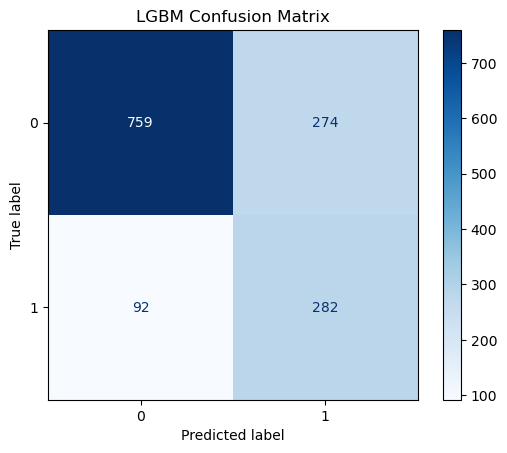

In [73]:
y_pred_rfc = best_lgbm_model.predict(X_test)
print(classification_report(y_test, y_pred_rfc))
ConfusionMatrixDisplay.from_estimator(best_lgbm_model, X_test, y_test, cmap='Blues')
plt.title("LGBM Confusion Matrix")
plt.show()

I save the best models, selected through grid search, into the models folder.

In [74]:
import os
import joblib

model_dir = os.path.join('..', 'models')

if not os.path.exists(model_dir):
    os.makedirs(model_dir)
    print(f"Created directory: {model_dir}")

models_to_save = {
    'logistic_regression': best_log_model,
    'random_forest': best_rfc_model,     
    'xgboost': best_xgb_model,
    'lgbm': best_lgbm_model            
}

print("Saving models...")
for model_name, model_object in models_to_save.items():
    filename = os.path.join(model_dir, f"{model_name}.joblib")
    joblib.dump(model_object, filename)
    print(f"Saved: {filename}")

print('Saving complete!')


Created directory: ../models
Saving models...
Saved: ../models/logistic_regression.joblib
Saved: ../models/random_forest.joblib
Saved: ../models/xgboost.joblib
Saved: ../models/lgbm.joblib
Saving complete!


# Step 6: Model Comparison

In [75]:
models_dict = {
    "Logistic Regression": best_log_model,
    "XGBoost": best_xgb_model,
    "Random Forest": best_rfc_model,
    "LightGBM": best_lgbm_model
}

comparison_results = []

for model_name, model in models_dict.items():
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    
    comparison_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })
    
    print(f"\n{model_name}:")
    print(f"  Accuracy:     {accuracy:.4f}")
    print(f"  Precision:    {precision:.4f}  (% of predicted churners that are true churners)")
    print(f"  Recall:       {recall:.4f}  (% of actual churners correctly identified)")
    print(f"  Specificity:  {specificity:.4f}  (% of non-churners correctly identified)")
    print(f"  F1-Score:     {f1:.4f}  (harmonic mean of precision & recall)")
    print(f"  ROC-AUC:      {roc_auc:.4f}  (probability the model ranks a churner higher than non-churner)")

comparison_df = pd.DataFrame(comparison_results).set_index("Model")
print(comparison_df.sort_values("ROC-AUC", ascending=False).to_string())


Logistic Regression:
  Accuracy:     0.7399
  Precision:    0.5069  (% of predicted churners that are true churners)
  Recall:       0.7861  (% of actual churners correctly identified)
  Specificity:  0.7231  (% of non-churners correctly identified)
  F1-Score:     0.6164  (harmonic mean of precision & recall)
  ROC-AUC:      0.8368  (probability the model ranks a churner higher than non-churner)

XGBoost:
  Accuracy:     0.7427
  Precision:    0.5107  (% of predicted churners that are true churners)
  Recall:       0.7674  (% of actual churners correctly identified)
  Specificity:  0.7338  (% of non-churners correctly identified)
  F1-Score:     0.6132  (harmonic mean of precision & recall)
  ROC-AUC:      0.8357  (probability the model ranks a churner higher than non-churner)

Random Forest:
  Accuracy:     0.7910
  Precision:    0.6471  (% of predicted churners that are true churners)
  Recall:       0.4706  (% of actual churners correctly identified)
  Specificity:  0.9071  (% of 

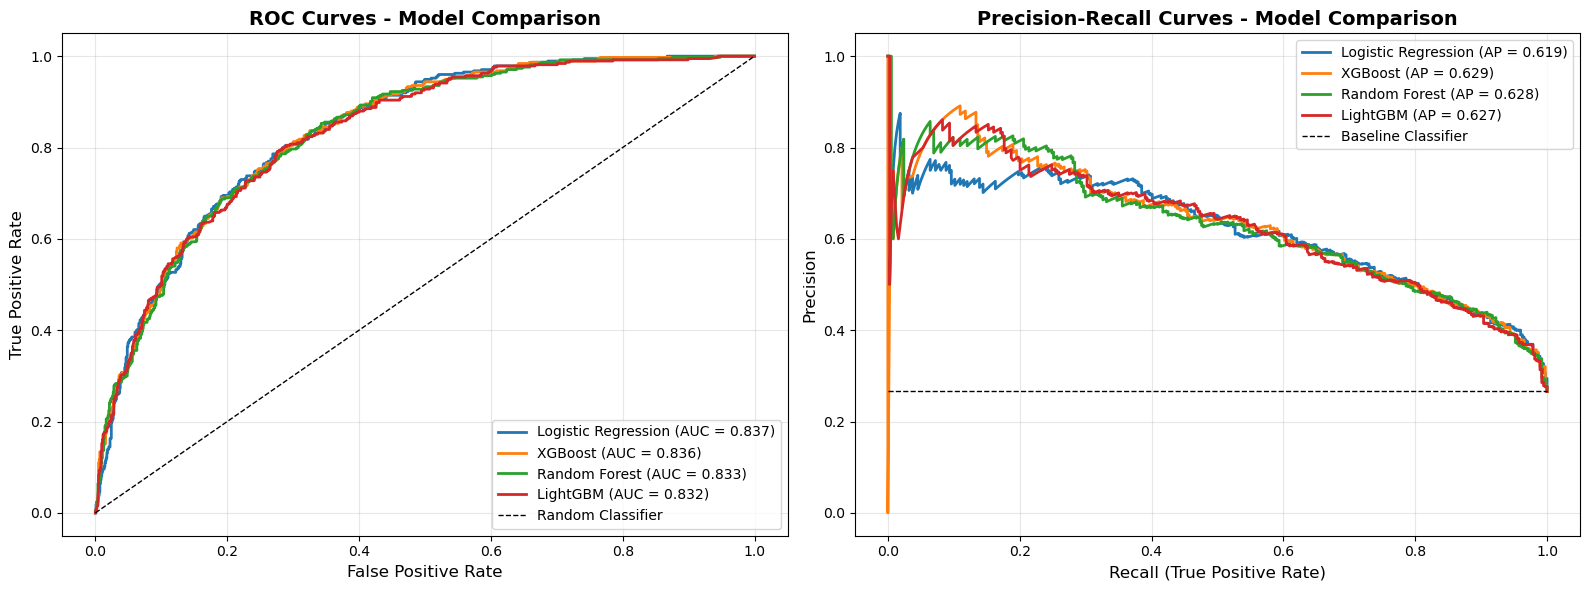

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for model_name, model in models_dict.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {roc_auc:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)

for model_name, model in models_dict.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)
    axes[1].plot(recall, precision, linewidth=2, label=f"{model_name} (AP = {pr_auc:.3f})")

baseline_precision = (y_test == 1).sum() / len(y_test)
axes[1].plot([0, 1], [baseline_precision, baseline_precision], 'k--', linewidth=1, label='Baseline Classifier')
axes[1].set_xlabel('Recall (True Positive Rate)', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curves - Model Comparison', fontsize=14, fontweight='bold')
axes[1].legend(loc='best', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Prediction Summary

Realistically, the **Logistic Regression model is our most aggressive option**, capturing nearly 80% of churners. The **XGBoost is our second-most aggressive variant**. The **Random Forest is our conservative option**, greatly reducing wasted spend on false alarms, as well as catching significantly fewer churners. The **LightGBM is the stable option** between Logistic Regression and Random Forest models. 

**By choosing the model that aligns with our marketing budget and risk tolerance, we maximize our Return on Investment (ROI).**

**If approved by stakeholders**, could further develop:
- ROI calculator showing retention investment vs customer lifetime value by churn risk segment
- Executive dashboard with real-time churn risk scoring